# Series01-python: ECG signal analysis

## Goal
Display the ECG signal of leads I, II and III in standard units
(millivolts vs seconds).

## Steps
1. Load the raw data from `data/ECGu.txt`
2. Check the data is loaded correctly (values, shape)
3. Rescale the amplitudes to mV using the A/D gain
4. Build the time axis from the sampling frequency
5. Plot the ECG signal
6. Check the plot against what is expected of a normal ECG

## Setup

Libraries, equipment constants, and the functions used by the analysis.

In [16]:
# Imports
# numpy to manipulate the ECG data, matplotlib to plot it
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Constants from the equipment specification
AD_GAIN = 1024                 # A/D units per millivolt (see check cell)
SAMPLING_FREQUENCY_HZ = 1000
LEAD_NAMES = ["Lead I", "Lead II", "Lead III"]

In [18]:
# Functions

def convert_to_mV(ecg_raw, ad_gain=AD_GAIN):
    """Convert raw A/D units to millivolts."""
    return ecg_raw / ad_gain


def make_time_vector(n_samples, sampling_frequency=SAMPLING_FREQUENCY_HZ):
    """Build the time axis in seconds for a signal of n_samples.

    The data file contains no time column, so the time axis is reconstructed
    from the sampling frequency.
    """
    return np.arange(n_samples) / sampling_frequency


def estimate_baseline(one_lead):
    """Estimate the isoelectric line of one lead, in the units of the input.

    The median is used because the signal rests on the isoelectric line for
    most of each cardiac cycle; the mean would be pulled up by the QRS peaks.
    """
    return np.median(one_lead)


def find_qrs_times(one_lead, time_s, threshold_fraction=0.5, refractory_s=0.3):
    """Return the times (s) at which QRS complexes start in one lead.

    A complex is detected when the absolute deviation from baseline rises
    above threshold_fraction of its maximum. Absolute deviation is used so
    that leads with a downward main deflection are handled too.

    Detections closer together than refractory_s are merged: a single complex
    can cross the threshold several times in a noisy lead, and no real heart
    beats twice within 0.3 s (that would be 200 bpm).
    """
    deviation = np.abs(one_lead - estimate_baseline(one_lead))
    is_above = deviation > threshold_fraction * deviation.max()
    rising_edges = np.where(is_above[1:] & ~is_above[:-1])[0] + 1

    qrs_times = []
    for t in time_s[rising_edges]:
        if not qrs_times or t - qrs_times[-1] > refractory_s:
            qrs_times.append(t)
    return np.array(qrs_times)


def compute_heart_rate(qrs_times, duration_s):
    """Heart rate in beats per minute from detected QRS times."""
    return len(qrs_times) / duration_s * 60


def plot_all_leads(time_s, ecg_mV, lead_names=LEAD_NAMES):
    """Plot every lead of an ECG recording on a single set of axes."""
    plt.figure(figsize=(12, 4))
    plt.plot(time_s, ecg_mV)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.title("ECG signal in standard units")
    plt.legend(lead_names)
    plt.grid(True, alpha=0.3)
    plt.show()

## Analysis

Load the raw data, convert the amplitudes to millivolts, reconstruct the time
axis, and plot the three leads.

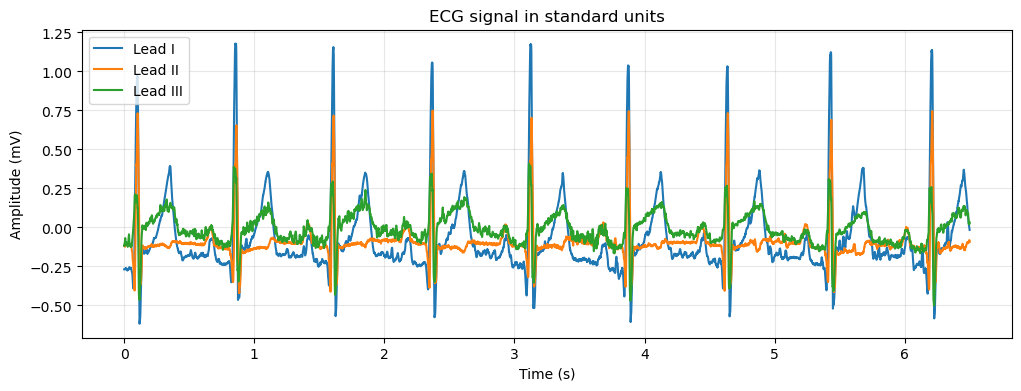

In [19]:
# Run the pipeline
ecg_raw = np.loadtxt("data/ECGu.txt")
ecg_mV = convert_to_mV(ecg_raw)
time_s = make_time_vector(len(ecg_raw))

plot_all_leads(time_s, ecg_mV)

## Checks

### Check of the rescaled ECG plot

**Are the number of timeseries correct?**
Yes. Three lines are plotted, one per column of `ecg_mV`, matching the three
leads (I, II, III) listed in the equipment specification.

**Are the number of samples correct?**
Yes. `ecg_raw.shape` is (6500, 3), and at a sampling frequency of 1000 Hz this
gives 6500 / 1000 = 6.5 s of recording. The x axis of the plot runs from 0 to
6.5 s, as expected.

**Are the values consistent with the expected range of an ECG signal?**
Yes, after correcting the conversion (see below). The observed range is
-0.62 to 1.18 mV, with the R wave peaking at about 1.18 mV in lead I. A normal
limb-lead R wave is on the order of 1 mV and stays below roughly 1.5-2 mV;

**Note on the conversion formula.**
Applying the formula as written in the instructions (raw x 1024 uV) gives a
range of about -630 to +1240 mV, roughly 1000 times larger than any
physiological ECG. Dividing by 1024 instead gives values in the expected
range. The gain of 1024 is therefore best read as A/D units per millivolt
(about 0.98 uV per unit), not microvolts per unit. This point should be
confirmed with the instructor.

**Additional check 1: is the heart rate plausible?**
9 QRS complexes are detected over the 6.5 s window, which gives
9 / 6.5 x 60 ~ 83 bpm. This falls in the normal sinus range of 60-100 bpm.
This check is useful because it validates the *time* axis independently of the
amplitude axis: an error in the assumed sampling frequency would produce an
implausible heart rate even if the mV values looked correct.

**Additional check 2: do the three leads agree with each other?**
Yes. All three leads return 9 complexes, at times agreeing to within about
20 ms, as they must, since the leads are simultaneous recordings of the same
heartbeats from different electrode pairs. Their amplitudes and polarities
differ, which is also expected. A time offset between leads would indicate a
loading or indexing error (for example, columns read in the wrong order).



In [21]:
# Numerical evidence for the checks above
duration_s = len(ecg_raw) / SAMPLING_FREQUENCY_HZ
qrs_times = find_qrs_times(ecg_mV[:, 0], time_s)

print(f"leads: {ecg_raw.shape[1]}, samples: {ecg_raw.shape[0]}, duration: {duration_s} s")
print(f"range: {ecg_mV.min():.2f} to {ecg_mV.max():.2f} mV")
print(f"heart rate: {compute_heart_rate(qrs_times, duration_s):.0f} bpm")

for i, name in enumerate(LEAD_NAMES):
    print(f"{name:9s} QRS at {np.round(find_qrs_times(ecg_mV[:, i], time_s), 3)}")

leads: 3, samples: 6500, duration: 6.5 s
range: -0.62 to 1.18 mV
heart rate: 83 bpm
Lead I    QRS at [0.089 0.843 1.593 2.354 3.111 3.862 4.623 5.416 6.195]
Lead II   QRS at [0.091 0.851 1.598 2.358 3.118 3.866 4.627 5.423 6.199]
Lead III  QRS at [0.111 0.839 1.588 2.348 3.107 3.858 4.618 5.413 6.19 ]
